Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import matplotlib.pyplot as plt

Vor-Definierung

In [2]:
df = pd.read_pickle("readData.pkl")

feature_cols = [
    "Age",
    "Gender",
    "Country",
    "Device",
    "GameGenre",
    "SessionCount",
    "AverageSessionLength"
]

X = df[feature_cols]
y = df["HighSpender"]

numeric_features = [
    "Age",
    "SessionCount",
    "AverageSessionLength"
]

categorical_features = [
    "Gender",
    "Country",
    "Device",
    "GameGenre"
]

# Preprocessing

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Modelle

models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistische Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# Scoring Metriken

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc"
}

Cross-Validation

In [3]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

# Standartabweichungen nicht vergessen

    cv_results.append({
        "Modell": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

,Modell,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Baseline,0.841270,0.000105,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
1,Logistische Regression,0.542642,0.048203,0.164346,0.021223,0.452083,0.028413,0.240366,0.023814,0.510970,0.026443
2,Random Forest,0.839286,0.000643,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.479530,0.033514
3,Gradient Boosting,0.835318,0.003960,0.066667,0.133333,0.002083,0.004167,0.004040,0.008081,0.480812,0.021710


Ansehlicher machen

In [4]:
cv_results_rounded = cv_results_df.copy()

numeric_cols = cv_results_rounded.select_dtypes(include="number").columns
cv_results_rounded[numeric_cols] = cv_results_rounded[numeric_cols].round(3)

display(cv_results_rounded)

,Modell,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Baseline,0.841,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.500,0.000
1,Logistische Regression,0.543,0.048,0.164,0.021,0.452,0.028,0.240,0.024,0.511,0.026
2,Random Forest,0.839,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.480,0.034
3,Gradient Boosting,0.835,0.004,0.067,0.133,0.002,0.004,0.004,0.008,0.481,0.022


Visualisierung

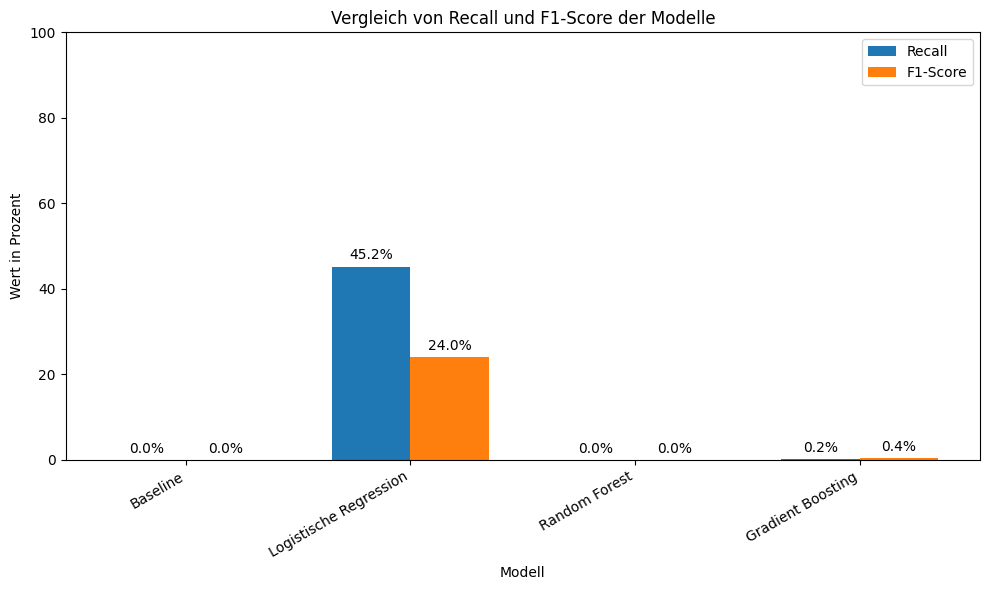

In [27]:
# Nur F1 & Recall, zeigen Unterschiede am Besten
plot_df = cv_results_df.copy()

# Nur relevante Spalten auswählen
plot_df = plot_df[
    [
        "Modell",
        "Recall Mean",
        "Recall Std",
        "F1 Mean",
        "F1 Std",
    ]
]

# Werte in Prozent
plot_df["Recall Mean Prozent"] = plot_df["Recall Mean"] * 100
plot_df["Recall Std Prozent"] = plot_df["Recall Std"] * 100
plot_df["F1 Mean Prozent"] = plot_df["F1 Mean"] * 100
plot_df["F1 Std Prozent"] = plot_df["F1 Std"] * 100

# Positionen der Balken
x = np.arange(len(plot_df["Modell"]))
width = 0.35

# Diagramm erstellen
fig, ax = plt.subplots(figsize=(10, 6))

# Sieht ohne Standartabweichung besser aus
recall_bars = ax.bar(
    x - width / 2,
    plot_df["Recall Mean Prozent"],
    width,
  #  yerr=plot_df["Recall Std Prozent"],
  #  capsize=5,
    label="Recall"
)

f1_bars = ax.bar(
    x + width / 2,
    plot_df["F1 Mean Prozent"],
    width,
  #  yerr=plot_df["F1 Std Prozent"],
  #  capsize=5,
    label="F1-Score"
)

# Achsen und Titel
ax.set_title("Vergleich von Recall und F1-Score der Modelle")
ax.set_xlabel("Modell")
ax.set_ylabel("Wert in Prozent")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Modell"], rotation=30, ha="right")
ax.set_ylim(0, 100)
ax.legend()

# Werte über den Balken anzeigen
for bars in [recall_bars, f1_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()